### Environment Setting

**n_classes  will change أنتبهي لها لبونه **

In [ ]:
! nvidia-smi

Sun Sep  8 15:33:56 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   72C    P8              13W /  70W |      0MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [ ]:
import torch

if torch.cuda.is_available():
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
else:
    print("Using CPU")

Using GPU: Tesla T4


In [ ]:
!pip install pytorch-lightning
!pip install transformers
!pip install farasapy
!pip install PyArabic

In [ ]:
# Import Basics
import pandas as pd
import json
import numpy as np
from tqdm.auto import tqdm
import pickle
import re
import os

In [ ]:
# Pytorch
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModel
from torch.utils.data import Dataset, DataLoader
from transformers import AdamW, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint
from pytorch_lightning.loggers import TensorBoardLogger
#from pytorch_lightning.metrics.functional import accuracy, f1, auroc
#https://torchmetrics.readthedocs.io/en/stable/metrics.html
#https://stackoverflow.com/questions/69139618/torchmetrics-does-not-work-with-pytorchlightning
from torchmetrics.functional import accuracy, f1_score, precision, recall, confusion_matrix
from sklearn.metrics import classification_report, multilabel_confusion_matrix,precision_recall_fscore_support
import torch.nn.functional as F

In [ ]:
# Visualisation
import seaborn as sns
from pylab import rcParams
import matplotlib.pyplot as plt
from matplotlib import rc

%matplotlib inline
%config InlineBackend.figure_format='retina'
sns.set(style='whitegrid', palette='muted', font_scale=1.2)
rcParams['figure.figsize'] = 4, 4
tqdm.pandas()

In [ ]:
pl.seed_everything(42)

INFO:lightning_fabric.utilities.seed:Seed set to 42


42

###  Load the Data

In [ ]:

# Specify the path to your Excel file
file_path = '/content/All_ArMPro_binary_train.jsonl'

# Read the Excel file
train_df = pd.read_json(file_path)

# Display the DataFrame
train_df.head()

,Unnamed: 0,paragraph_id,paragraph,label,LablePropaganda,LabelSentiment,LabelEmotion
0,0,PEMYqJCxhKkhaenb2jGFFU_001,ندوة «من سلب اسكندرون إلى سلب فلسطين» على مدرج...,True,true,neutral,none
1,1,MIS_2214-eurl_04_016,بعد استقلال الجزائر، تزوجت جميلة بوحيرد بالمحا...,True,true,positive,happiness
2,2,MIS_855-eurl_01_002,وفي الوقت الذي لم تفصح فيه الخاطر عن فحوى ما ح...,True,true,neutral,none
3,3,AFP_336-eurl_01_015,"وبدورها، كتبت نور الهجري، على فيسبوك "" احتفال ...",True,true,positive,happiness
4,4,AFP_161-eurl_01_013,وظل بوتفليقة في سدة الرئاسة الجزائرية نحو 20 ع...,True,true,negative,none


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6002 entries, 0 to 6001
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Unnamed: 0       6002 non-null   int64 
 1   paragraph_id     6002 non-null   object
 2   paragraph        6002 non-null   object
 3   label            6002 non-null   bool  
 4   LablePropaganda  6002 non-null   object
 5   LabelSentiment   6002 non-null   object
 6   LabelEmotion     6002 non-null   object
dtypes: bool(1), int64(1), object(5)
memory usage: 287.3+ KB


In [ ]:

# Specify the path to your Excel file
file_path = '/content/All_ArMPro_binary_dev.jsonl'

# Read the Excel file
dev_df = pd.read_json(file_path)



# Display the DataFrame
dev_df.head()

,Unnamed: 0,paragraph_id,paragraph,label,LablePropaganda,LabelSentiment,LabelEmotion
0,0,MIS_1062-eurl_04_008,وقالت الحكومة السودانية الثلاثاء إنها رفضت مقت...,False,false,negative,sadness
1,1,c5kikhveqPRvXDK89HE8go_004,وأكد الأستاذ نصر باغريب، أن إنشاء مركز التدريب...,True,true,positive,happiness
2,2,MIS_1049-curl_05_006,وتلعب العوامل الإقليمية والعرقية والاجتماعية و...,False,false,neutral,none
3,3,MIS_688-curl_03_012,وسيتابع موقع الصحراوي هذا الموضوع عن كثب خلال ...,True,true,neutral,none
4,4,MIS_2200-eurl_04_008,المحاور: الولايات المتحدة الأميركية حذرت رعايا...,False,false,negative,fear


In [ ]:
dev_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 672 entries, 0 to 671
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Unnamed: 0       672 non-null    int64 
 1   paragraph_id     672 non-null    object
 2   paragraph        672 non-null    object
 3   label            672 non-null    bool  
 4   LablePropaganda  672 non-null    object
 5   LabelSentiment   672 non-null    object
 6   LabelEmotion     672 non-null    object
dtypes: bool(1), int64(1), object(5)
memory usage: 32.3+ KB


In [ ]:
# Specify the path to your Excel file
file_path = '/content/All_ArMPro_binary_test.jsonl'

# Read the Excel file
test_df = pd.read_json(file_path)



# Display the DataFrame
test_df.head()

,Unnamed: 0,paragraph_id,paragraph,label,LablePropaganda,LabelSentiment,LabelEmotion
0,0,fEavdmiweHdA8Vu7UfvZw2_011,فيما أشار الدكتور أحمد خليفة، الرئيس التنفيذي ...,False,false,neutral,none
1,1,NU3oAkQa2nrMWG8VKvPe9r_010,"وقال ""لديه الموهبة والجودة، الأمر لا يتعلق بتس...",True,true,positive,happiness
2,2,Uqd2Xgwmgqbi4ZLGaBUMTZ_006,الرعاية الصحية والنفسية للأطفال هي من بين الاو...,True,true,positive,happiness
3,3,MIS_855-eurl_01_005,- جرى تداول معلومات مؤخرا عن رغبة دول الحصار ب...,True,true,positive,happiness
4,4,MIS_403-curl_02_002,وجاء إعلان السلطات السورية لينفي معلومات نشرها...,False,false,neutral,none


In [ ]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1326 entries, 0 to 1325
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Unnamed: 0       1326 non-null   int64 
 1   paragraph_id     1326 non-null   object
 2   paragraph        1326 non-null   object
 3   label            1326 non-null   bool  
 4   LablePropaganda  1326 non-null   object
 5   LabelSentiment   1326 non-null   object
 6   LabelEmotion     1326 non-null   object
dtypes: bool(1), int64(1), object(5)
memory usage: 63.6+ KB


In [ ]:
train_dev_df = pd.concat([train_df, dev_df], ignore_index=True)
train_dev_test_df = pd.concat([train_dev_df, test_df], ignore_index=True)

In [ ]:
print(train_df.shape)
print(dev_df.shape)
print(test_df.shape)
print(train_dev_df.shape)
print(train_dev_test_df.shape)

(6002, 7)
(672, 7)
(1326, 7)
(6674, 7)
(8000, 7)


In [ ]:
train_df.columns

Index(['Unnamed: 0', 'paragraph_id', 'paragraph', 'label', 'LablePropaganda',
       'LabelSentiment', 'LabelEmotion'],
      dtype='object')

In [ ]:
# Prepare dataframe for sentiment
train_df = train_df[['paragraph','LabelSentiment']]
dev_df = dev_df[['paragraph','LabelSentiment']]
test_df = test_df[['paragraph','LabelSentiment']]
dev_df.head()

# Prepare dataframe for Emotion
# train_df = train_df[['paragraph','LabelEmotion']]
# dev_df = dev_df[['paragraph','LabelEmotion']]
# test_df = test_df[['paragraph','LabelEmotion']]
# dev_df.head()

,paragraph,LabelSentiment
0,وقالت الحكومة السودانية الثلاثاء إنها رفضت مقت...,negative
1,وأكد الأستاذ نصر باغريب، أن إنشاء مركز التدريب...,positive
2,وتلعب العوامل الإقليمية والعرقية والاجتماعية و...,neutral
3,وسيتابع موقع الصحراوي هذا الموضوع عن كثب خلال ...,neutral
4,المحاور: الولايات المتحدة الأميركية حذرت رعايا...,negative


In [ ]:
train_df['LabelSentiment'].unique()
#train_df['LabelEmotion'].unique()

array(['neutral', 'positive', 'negative'], dtype=object)

In [ ]:
dev_df['LabelSentiment'].unique()
#dev_df['LabelEmotion'].unique()

array(['negative', 'positive', 'neutral'], dtype=object)

In [ ]:
test_df['LabelSentiment'].unique()
#test_df['LabelEmotion'].unique()

array(['neutral', 'positive', 'negative'], dtype=object)

In [ ]:
# Label mapping for sentiment
mapping = {'neutral': 0, 'positive': 1,'negative':2}

train_df['LabelSentiment'] = train_df['LabelSentiment'].apply(lambda x: mapping[x])
dev_df['LabelSentiment'] = dev_df['LabelSentiment'].apply(lambda x: mapping[x])
test_df['LabelSentiment'] = test_df['LabelSentiment'].apply(lambda x: mapping[x])


# Label mapping for Emotion
# mapping = {'none': 0, 'happiness': 1,'sadness':2,'anger':3,'fear':4}

# train_df['LabelEmotion'] = train_df['LabelEmotion'].apply(lambda x: mapping[x])
# dev_df['LabelEmotion'] = dev_df['LabelEmotion'].apply(lambda x: mapping[x])
# test_df['LabelEmotion'] = test_df['LabelEmotion'].apply(lambda x: mapping[x])


<ipython-input-21-5e62fd87d447>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['LabelSentiment'] = train_df['LabelSentiment'].apply(lambda x: mapping[x])


In [ ]:
train_df['LabelSentiment'].dtype
#train_df['LabelEmotion'].dtype

dtype('int64')

In [ ]:
train_df.sample(3)

,paragraph,LabelSentiment
1782,"وتقول وزارة الدفاع البريطانية إن ""قادة روسيا ي...",2
3917,"وفي واحدة من أشهر أغنياتها تقول فيروز ""حبيتك ب...",0
221,لكن أستاذ التاريخ والآثار في الجامعة الإسلامية...,2


In [ ]:
class_names = ['neutral', 'positive','negative']
#class_names=['none','happiness','sadness','anger','fear']

### Data Analysis (training set)

In [ ]:
train_df['LabelSentiment'].value_counts()
#train_df['LabelEmotion'].value_counts()


,count
LabelSentiment,
2,2568
1,2158
0,1276


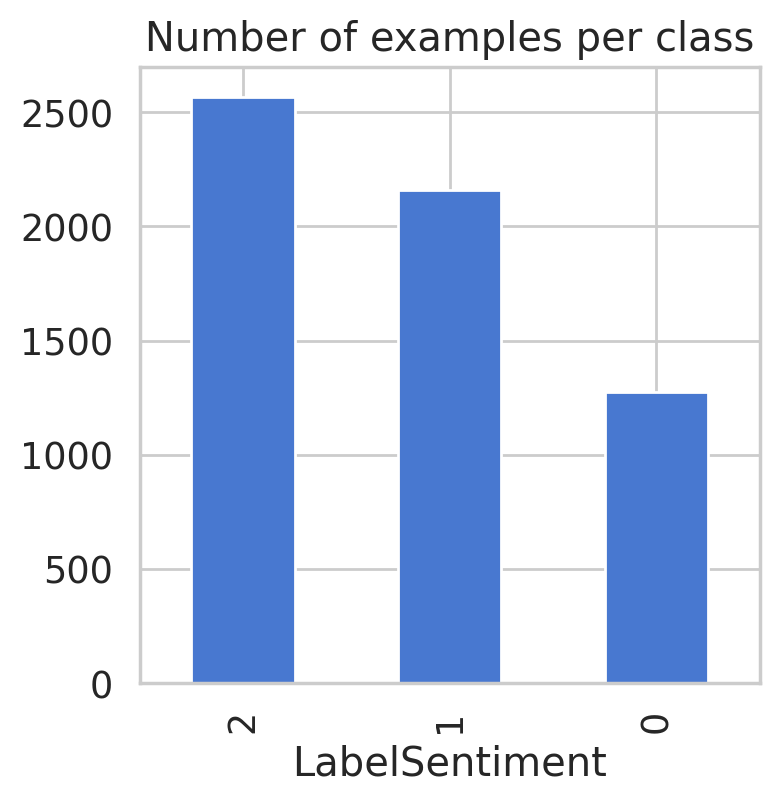

In [ ]:
train_df['LabelSentiment'].value_counts().sort_values(ascending=False).plot(kind="bar")
#train_df['LabelEmotion'].value_counts().sort_values(ascending=False).plot(kind="bar")

plt.title("Number of examples per class");




### Data Preprocessing

In [ ]:
!git clone https://github.com/aub-mind/arabert/

fatal: destination path 'arabert' already exists and is not an empty directory.


In [ ]:
model_name = "bert-base-arabertv02"

In [ ]:
from arabert.preprocess import ArabertPreprocessor
import string
import re
import nltk
from nltk.corpus import stopwords

# Download stopwords if not already downloaded
nltk.download('stopwords')

# Arabic stop words
stop_words = set(stopwords.words('arabic'))



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
#https://github.com/aub-mind/arabert/blob/master/preprocess.py
# Default values of parameters:
#ArabertPreprocessor(model_name: str, remove_html_markup: bool=True, replace_urls_emails_mentions: bool=True, strip_tashkeel: bool=True,
#                    strip_tatweel: bool=True, insert_white_spaces: bool=True, remove_non_digit_repetition: bool=True, keep_emojis: bool=None,
#                    replace_slash_with_dash: bool=None, map_hindi_numbers_to_arabic: bool=None, apply_farasa_segmentation: bool=None)

arabert_prep = ArabertPreprocessor(model_name=model_name, remove_html_markup=True, replace_urls_emails_mentions=True, strip_tashkeel=True,strip_tatweel=True,
insert_white_spaces=True, remove_non_digit_repetition=True, keep_emojis=False,
replace_slash_with_dash=True, map_hindi_numbers_to_arabic=True, apply_farasa_segmentation=True)

[2024-09-08 15:34:15,101 - farasapy_logger - WARNING]: Be careful with large lines as they may break on interactive mode. You may switch to Standalone mode for such cases.


In [ ]:
def preprocess_arabic_text(text):
    # Step 1: Apply Arabert preprocessing
    text = arabert_prep.preprocess(text)

    # Step 2: Remove non-Arabic text (optional if Arabert already filters this)
    text = re.sub(r'[^\u0600-\u06FF\s]', '', text)

    # Step 3: Character normalization
    text = re.sub(r'\bء', 'ا', text)  # Replace 'ء' at the beginning of words
    text = re.sub(r'[ؤ]', 'و', text)  # Replace 'ؤ' with 'و'
    text = re.sub("[إأآا]", "ا", text)
    text = re.sub("ى", "ي", text)
    text = re.sub("ؤ", "ء", text)
    text = re.sub("ئ", "ء", text)
    text = re.sub("ة", "ه", text)
    text = re.sub("گ", "ك", text)

    # Step 4: Remove punctuation

    arabic_punctuations = '''`÷×؛<>_()*&^%][ـ،/:"؟.,'{}~¦+|!”…“–ـ'''
    english_punctuations = string.punctuation
    punctuations_list = arabic_punctuations + english_punctuations
    translator = str.maketrans('', '', punctuations_list)
    text= text.translate(translator)


    # Step 5: Stop word elimination
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    processed_text = ' '.join(filtered_words)

    return processed_text


In [ ]:
# check pre-processing by taking sample before applied to all dataset
sample_text = train_df.iloc[41]
sample_text

,41
paragraph,وأدى حسني، واسمه شقرون حسني، الكثير من الأغاني...
LabelSentiment,1


In [ ]:
sample_text.paragraph

'وأدى حسني، واسمه شقرون حسني، الكثير من الأغاني، إلى أن برز طابعه العاطفي الخاص الذي ألهب مشاعر ملايين الشباب، ليس في الجزائر فحسب بل وفي البلدان المغاربية، وفي فرنسا وعواصم تواجد الجالية المغاربية.'

In [ ]:
print(type(sample_text.paragraph))

<class 'str'>


In [ ]:
#appplied only arabert preprocessing
preprocessed_text = arabert_prep.preprocess(sample_text.paragraph)
preprocessed_text

'وأدى حسني ، واسمه شقرون حسني ، الكثير من الأغاني ، إلى أن برز طابعه العاطفي الخاص الذي ألهب مشاعر ملايين الشباب ، ليس في الجزائر فحسب بل وفي البلدان المغاربية ، وفي فرنسا وعواصم تواجد الجالية المغاربية .'

In [ ]:
sample_preprocessed_text= preprocess_arabic_text(preprocessed_text)
sample_preprocessed_text

'وادي حسني واسمه شقرون حسني الكثير الاغاني الي ان برز طابعه العاطفي الخاص الهب مشاعر ملايين الشباب الجزاءر فحسب وفي البلدان المغاربيه وفي فرنسا وعواصم تواجد الجاليه المغاربيه'

In [ ]:
print(type(sample_preprocessed_text))

<class 'str'>


In [ ]:
sample_target=sample_text.LabelSentiment
#sample_target=sample_text.LabelEmotion
print(sample_target)
print(type(sample_target))

1
<class 'numpy.int64'>


In [ ]:
# Apply preprocessing function to all the DataFrame
train_df['paragraph'] = train_df['paragraph'].apply(preprocess_arabic_text)
dev_df['paragraph'] = dev_df['paragraph'].apply(preprocess_arabic_text)
test_df['paragraph'] = test_df['paragraph'].apply(preprocess_arabic_text)

In [ ]:
# Sanity check on the dataset after arabert processing
list(train_df['paragraph'][0:120])

['ندوه سلب اسكندرون الي سلب فلسطين علي مدرج دار البعث دمشق بمشاركه القومي العميد عضو المكتب السياسي القومي طارق الاحمد انقاذ بلادنا يكون بفتح الحدود علي محور بيروت دمشق بغداد ضمن اهم حامل نضالي سوريه الطبيعيه',
 'استقلال الجزاءر تزوجت جميله بوحيرد بالمحامي الفرنسي جاك فيرجس عام الي وقد اشهر اسلامه واتخذ اسم منصور ومنحت الجنسيه الجزاءريه وبات يلقب محامي الارض وقد انجبت بوحيرد الابناء مريم والياس',
 'وفي الوقت تفصح الخاطر فحوي حمله وزير الخارجيه الكويتي احمد بن ناصر المحمد الصباح خلال زيارته الاخيره الي قطر اطار الوساطه الكويتيه لحل الازمه الخليجيه جددت الخاطر تمسك دوله قطر بالحوار المشروط باسس وركاءز معينه لحل الازمه الخليجيه اهمها الاحترام المتبادل يحفظ سياده الدول ويضمن عدم التعدي علي استقلاليه القرارات',
 'وبدورها كتبت نور الهجري علي فيسبوك احتفال بعيد الانوار البحرين مستغربا خاصه وان سفيره البحرين السابقه الولايات المتحده كانت هدي نونو يهوديه عربيه تذكير بالتعايش والتسامح',
 'وظل بوتفليقه سده الرءاسه الجزاءريه عاما ولم يظهر بشكل علني عام الا نادرا اصابته بجلطه دماغيه عام',
 'واقتصرت

## Transformer Fine-Tuning

For new model, change **selectedModel** variable, this will effect 3 lines:
1. tokenizer =
2. model =
3. AraProPredictor class


In [ ]:

#'aubmindlab/bert-base-arabertv2' #pre-segmenation
#'aubmindlab/bert-base-arabertv02' #not segmentaion
#'xlm-roberta-base'
#'asafaya/bert-base-arabic'
#'CAMeL-Lab/bert-base-arabic-camelbert-msa'
selectedModel = 'aubmindlab/bert-base-arabertv2'

### Encoding

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(selectedModel)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [ ]:
model = AutoModel.from_pretrained(selectedModel)

In [ ]:
# Print the default configuration of the model
print(model.config)

BertConfig {
  "_name_or_path": "aubmindlab/bert-base-arabertv2",
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "transformers_version": "4.44.2",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 64000
}



In [ ]:
encoding = tokenizer.encode_plus(
  str(sample_target), ##Extra
  sample_preprocessed_text,
  add_special_tokens=True,
  max_length=128, # Tokens in each sequence
  return_token_type_ids=True,
  padding="max_length",
  return_attention_mask=True,
  return_tensors='pt',
)


In [ ]:
encoding.keys()

dict_keys(['input_ids', 'token_type_ids', 'attention_mask'])

In [ ]:
encoding['input_ids'].shape , encoding['attention_mask'].shape,encoding['token_type_ids'].shape

(torch.Size([1, 128]), torch.Size([1, 128]), torch.Size([1, 128]))

In [ ]:
#squeeze() function is used to remove dimensions of size 1 from the tensor, as it is clear from above it is size of[1,128]
encoding['input_ids'].squeeze()[:51]

tensor([   33,    50,    34,  4314,  5742,  3035, 48103, 14777,   313,  5742,
        15209,   605,  1793,  5300,  4308,   312,  6264,  4570,   223,  6958,
         4528,   209, 56145, 13246,   221,  3593,  2146, 16181,  5880, 11000,
          307,   211,  2761,   472,  5660, 26762,  5696,  7214,  4080,  5359,
         5660,  2164,  8463, 56394,   199,  3182, 27099, 59521,  7214,  4080,
         5359])

In [ ]:
encoding['token_type_ids'].squeeze()[:51]

tensor([0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1])

In [ ]:
encoding['attention_mask'].squeeze()[:51]

tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1])

In [ ]:

# Extract the first 51 token IDs and their corresponding token type IDs
input_ids = encoding['input_ids'].squeeze()[:51]
tokens = tokenizer.convert_ids_to_tokens(input_ids)
token_type_ids = encoding['token_type_ids'].squeeze()[:51]


# Create a DataFrame to display the results in a table format
df = pd.DataFrame({
    'Input ID': input_ids.tolist(),
    'Token': tokens,
    'Token Type ID': token_type_ids.tolist()
})

# Print the DataFrame
print(df)

    Input ID   Token  Token Type ID
0         33   [CLS]              0
1         50       1              0
2         34   [SEP]              0
3       4314    وادي              1
4       5742    حسني              1
5       3035     واس              1
6      48103    ##مه              1
7      14777     شقر              1
8        313    ##ون              1
9       5742    حسني              1
10     15209     الك              1
11       605   ##ثير              1
12      1793     الا              1
13      5300  ##غاني              1
14      4308     الي              1
15       312      ان              1
16      6264     برز              1
17      4570    طابع              1
18       223     ##ه              1
19      6958     الع              1
20      4528   ##اطف              1
21       209     ##ي              1
22     56145   الخاص              1
23     13246     اله              1
24       221     ##ب              1
25      3593   مشاعر              1
26      2146  ملايين        

In [ ]:
output = model(encoding["input_ids"], encoding["attention_mask"])
output

BaseModelOutputWithPoolingAndCrossAttentions(last_hidden_state=tensor([[[ 0.0415,  0.2715,  0.0920,  ...,  0.2033, -0.1239, -0.1409],
         [-0.0801, -0.2075,  0.1303,  ...,  0.0623,  0.0859,  0.8438],
         [-0.2056, -0.0116,  0.0412,  ...,  0.3767, -0.6297, -0.7501],
         ...,
         [ 0.1787, -0.0289,  0.4718,  ...,  0.4323, -0.2690, -0.1406],
         [ 0.1997, -0.0445,  0.3136,  ...,  0.4224, -0.2030, -0.0563],
         [ 0.0223, -0.1113,  0.2214,  ...,  0.3098, -0.1830,  0.1303]]],
       grad_fn=<NativeLayerNormBackward0>), pooler_output=tensor([[ 4.5664e-01,  9.9950e-01, -9.9071e-01, -8.9182e-01, -2.2179e-01,
          7.2377e-01,  9.1545e-01, -9.4107e-01, -5.2874e-01, -1.5000e-01,
         -9.9538e-01,  9.9981e-01, -2.7543e-01, -3.0492e-01,  2.2751e-01,
         -1.4125e-02,  4.0504e-02,  9.9932e-01,  9.6567e-01, -9.9907e-01,
         -9.7423e-01, -2.3598e-01,  9.7134e-02,  9.9624e-01, -2.9147e-01,
          3.7906e-01, -9.8850e-01,  1.0060e-01, -1.4062e-01,  9.999

### Prepare Dataset

**Data split**

train:val:test => 70:15:15

In [ ]:
token_counts = []

for _, row in train_df.iterrows():
  token_count = len(tokenizer.encode(row.paragraph, max_length=512, truncation=True))
  token_counts.append(token_count)

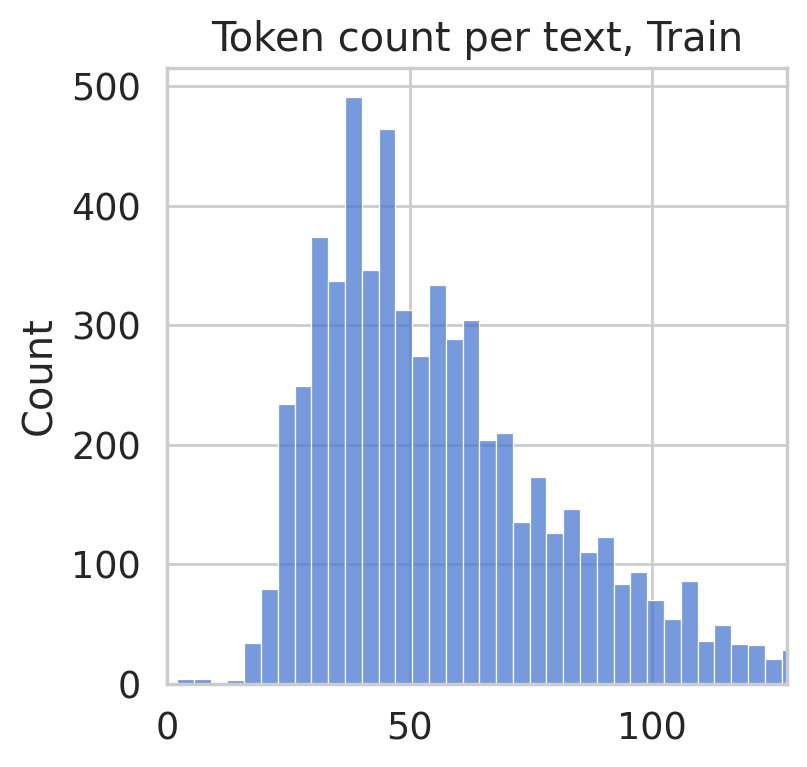

In [ ]:
sns.histplot(token_counts)
plt.xlim([0, 128]);
plt.title("Token count per text, Train");

In [ ]:
max(token_counts), min(token_counts), sum(token_counts) / len(token_counts)

(158, 2, 56.94801732755748)

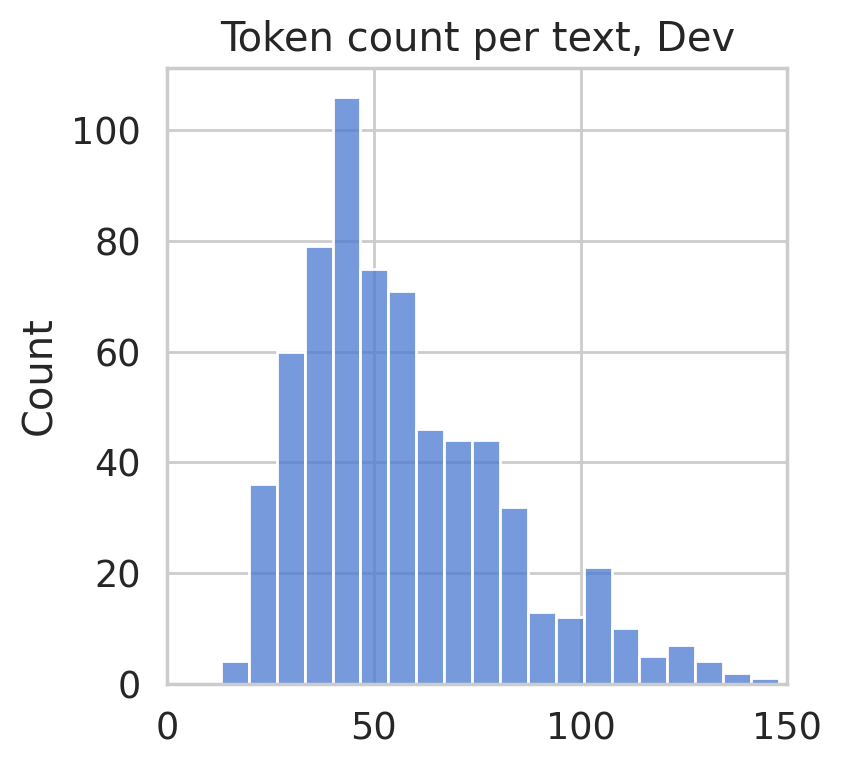

In [ ]:
token_counts = []
for _, row in dev_df.iterrows():
  token_count = len(tokenizer.encode(
    row["paragraph"],
    max_length=512,
    truncation=True
  ))
  token_counts.append(token_count)
sns.histplot(token_counts)
plt.xlim([0, 150]);
plt.title("Token count per text, Dev");

In [ ]:
max(token_counts), min(token_counts), sum(token_counts) / len(token_counts)


(148, 13, 56.614583333333336)

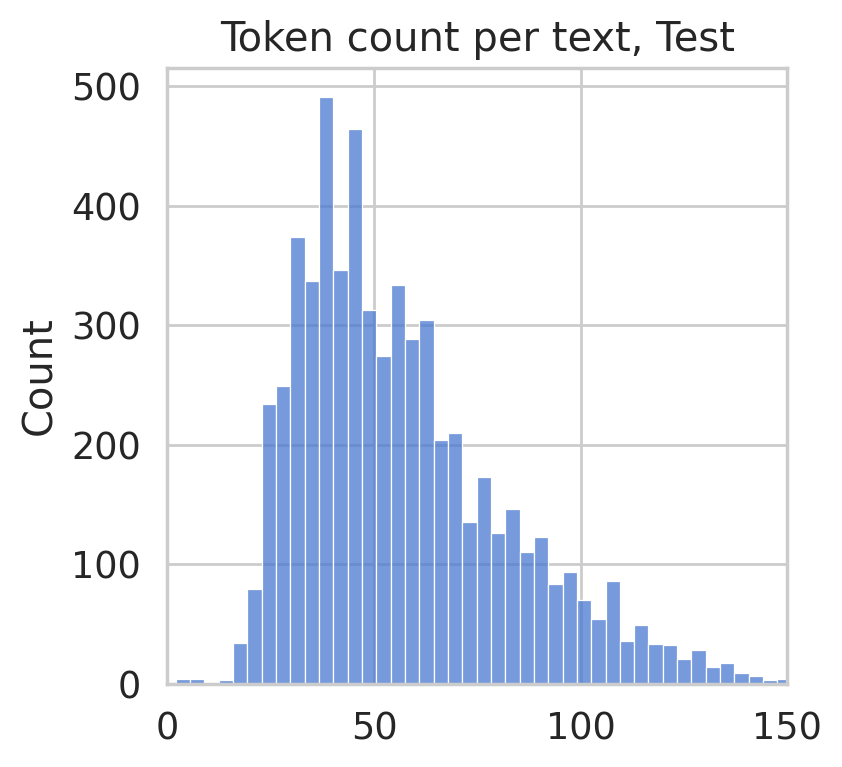

In [ ]:
token_counts = []
for _, row in train_df.iterrows():
  token_count = len(tokenizer.encode(
    row["paragraph"],
    max_length=512,
    truncation=True
  ))
  token_counts.append(token_count)
sns.histplot(token_counts)
plt.xlim([0, 150]);
plt.title("Token count per text, Test");

In [ ]:
max(token_counts), min(token_counts), sum(token_counts) / len(token_counts)


(158, 2, 56.94801732755748)

In [ ]:
MAX_TOKEN_COUNT = 265 #Selection is based on the previous graph

In [ ]:
class AraProDataset(Dataset):

  def __init__(
      self,
      data: pd.DataFrame,
      tokenizer: AutoTokenizer,
      text_preprocessor=None,
      max_token_len: int = MAX_TOKEN_COUNT
    ):
    self.data = data
    self.tokenizer = tokenizer
    self.text_preprocessor = text_preprocessor
    self.max_token_len = max_token_len

  def __len__(self):
    return len(self.data)



  def __getitem__(self, index: int):
    data_row = self.data.iloc[index]
    text = data_row.paragraph
    # target = data_row.label ##EXTRA - This line caused the error.  Check the DataFrame column names and correct this.
    if self.text_preprocessor is not None:
      text = self.text_preprocessor.preprocess(text)


    encoding = self.tokenizer.encode_plus(
      text,
      #target, ##EXTRA
      add_special_tokens=True,
      max_length=self.max_token_len,
      return_token_type_ids=True,
      padding="max_length",
      truncation=True,
      return_attention_mask=True, # to make sure each sequence is maximum of max length
      return_tensors='pt', #return it as pytorch
    )

    return dict(
      text=text,
      input_ids=encoding["input_ids"].flatten(), # flatten to remove X dimension
      attention_mask=encoding["attention_mask"].flatten(),
      #For Sentiment
      labels = torch.tensor(data_row.LabelSentiment, dtype=torch.long) #classification task, convert labels into tens of intigiers - This line was also incorrect. Changed 'label' to 'LabelSentiment' to match the column name in the DataFrame
      #labels = torch.tensor(data_row.LabelEmotion, dtype=torch.long)
    )

**Create the training dataset:**
(to make sure every thing is going right)

In [ ]:
train_dataset = AraProDataset(train_df, tokenizer, max_token_len=MAX_TOKEN_COUNT)

## to be sure every thing is going right:
print (len(train_dataset) == len(train_df))

True


In [ ]:
sample_item = train_dataset[50]
sample_item

{'text': 'انه بالبحث تبين ان الفيديو يعود لعام ويعود لمظاهره الكويت يبدو ان زيف التعليق الاصوات والتعليق المصاحب للفيديو علي مستوي عال الحرفيه',
 'input_ids': tensor([   33, 14518,  4350,  2652,  3212,   312, 32800,  3318,  2245, 13132,
           296, 37605,   353,   462,  1401,   223, 15209,  2618,  2326,   312,
         15071,  1152, 20737,   198,  1793, 27927,   440, 25843, 20737,   198,
          7214, 51234,   162,   429, 34911,   218,   421,  2482,   524, 10160,
           477,  7952,    34,    31,    31,    31,    31,    31,    31,    31,
            31,    31,    31,    31,    31,    31,    31,    31,    31,    31,
            31,    31,    31,    31,    31,    31,    31,    31,    31,    31,
            31,    31,    31,    31,    31,    31,    31,    31,    31,    31,
            31,    31,    31,    31,    31,    31,    31,    31,    31,    31,
            31,    31,    31,    31,    31,    31,    31,    31,    31,    31,
            31,    31,    31,    31,    31,    31,  

In [ ]:
sample_item.keys()

dict_keys(['text', 'input_ids', 'attention_mask', 'labels'])

In [ ]:
print(sample_item['input_ids'].shape)
print(sample_item['attention_mask'].shape)

torch.Size([265])
torch.Size([265])


In [ ]:
sample_item["text"]

'انه بالبحث تبين ان الفيديو يعود لعام ويعود لمظاهره الكويت يبدو ان زيف التعليق الاصوات والتعليق المصاحب للفيديو علي مستوي عال الحرفيه'

In [ ]:
sample_item["labels"]

tensor(0)

In [ ]:
print(tokenizer.convert_ids_to_tokens(sample_item ['input_ids'].squeeze()[:50]))

['[CLS]', 'انه', 'بال', '##بحث', 'تبين', 'ان', 'الفي', '##ديو', 'يعود', 'لع', '##ام', 'ويع', '##ود', 'لم', '##ظاهر', '##ه', 'الك', '##ويت', 'يبدو', 'ان', 'زيف', 'الت', '##علي', '##ق', 'الا', '##صو', '##ات', 'والت', '##علي', '##ق', 'الم', '##صاحب', 'ل', '##لف', '##يدي', '##و', 'علي', 'مستوي', 'عال', 'الح', '##رف', '##يه', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']


**Bert base:**

12 layer, 768 hidden units, 136M parameters

In [ ]:
bert_model = AutoModel.from_pretrained(selectedModel, return_dict=True)
sample_batch = next(iter(DataLoader(train_dataset, batch_size=8, num_workers=2)))
sample_batch["input_ids"].shape, sample_batch["attention_mask"].shape

(torch.Size([8, 265]), torch.Size([8, 265]))

In [ ]:
output = bert_model(sample_batch["input_ids"], sample_batch["attention_mask"])

In [ ]:
output.last_hidden_state.shape, output.pooler_output.shape

(torch.Size([8, 265, 768]), torch.Size([8, 768]))

In [ ]:
bert_model.config.hidden_size

768

### Training Setup

In [ ]:
class AraProDataModule(pl.LightningDataModule):

  def __init__(
      self,
      train_df,
      val_df,
      test_df,
      tokenizer,
      text_preprocessor=None,
      batch_size=8, ## This default value
      token_len=128 ## This default value
    ):
    super().__init__()
    self.batch_size = batch_size
    self.train_df = train_df
    self.val_df = val_df
    self.test_df = test_df
    self.tokenizer = tokenizer
    self.text_preprocessor = text_preprocessor
    self.token_len = token_len

  ## setup function for loading the train and test sets
  def setup(self, stage=None):
    self.train_dataset = AraProDataset(
      self.train_df,
      self.tokenizer,
      #self.label_columns,
      self.text_preprocessor,
      self.token_len
    )

    self.val_dataset = AraProDataset(
      self.val_df,
      self.tokenizer,
      self.text_preprocessor,
      self.token_len
    )

    self.test_dataset = AraProDataset(
      self.test_df,
      self.tokenizer,
      self.text_preprocessor,
      self.token_len
    )

  def train_dataloader(self):
    return DataLoader(
      self.train_dataset,
      batch_size=self.batch_size,
      shuffle=True, #########
      num_workers=os.cpu_count() # or num_workers=4
    )


  def val_dataloader(self):
    return DataLoader(self.val_dataset, batch_size=1, num_workers=os.cpu_count()) # or num_workers=4

  def test_dataloader(self):
    return DataLoader(self.test_dataset, batch_size=1, num_workers=os.cpu_count()) # or num_workers=4

In [ ]:
N_EPOCHS = 5
BATCH_SIZE = 8

data_module = AraProDataModule(train_df, dev_df, test_df, tokenizer, batch_size=BATCH_SIZE, token_len=MAX_TOKEN_COUNT)
data_module.setup()

In [ ]:
# to be sure every thing is going right:
for batch in data_module.train_dataloader():
  print("the length of batch", len(batch))
  print("the input id shape", batch["input_ids"].shape,"the attention_mask shape", batch["attention_mask"].shape) #first dim should be batch size, and second dim should be maximum token len
  print(batch["labels"].shape) #dim should be maximum token len
  print("_____________________________________________________________________________________________________________")
  print(batch)
  break

the length of batch 4
the input id shape torch.Size([8, 265]) the attention_mask shape torch.Size([8, 265])
torch.Size([8])
_____________________________________________________________________________________________________________
{'text': ['علي اتهموا بشكل تامري ضباط يتبعون لمجلس اسايش اقليم كوردستان اتخاذ اجراءات قانونيه تقديرا للمجلس ولتنميق موامرتهم اكثر وليس اعتقالهم علي شاكله مايفعل العصابات والحقاءهم بتلك التهم اللاانسانيه نظرا لعاءديه المجلس لموسسات اقليم كوردستان الرسميه ونري ان الديمقراطي استغل مره اخري الموسسات الوطنيه لتنفيذ مخططاتهم الخبيثه', 'وقالت عاءشه شرفي مهندسه نظام الدفع وقت سابق سيكون الامر مرهقا للاعصاب بكل تاكيد ان مجرد التفكير الامر يصيبني بقشعريره لدينا نظام حمايه الاعطال يمكن ان يعوض اي مشاكل تحدث اثناء عمليه الكبح لذلك اعتقد اننا وضع جيد لدخول مدار المريخ بنجاح', 'يهدف النهج الي القضاء تماما علي انتشار فيروس كورونا منطقه او بلد بفضل تدابير صارمه تتخذ ان تظهر اصابات وتقترن باحكام السيطره علي بوره الوباء خلال فحوص الكشف وتتبع المخالطين والعزل وبموازاه تتواصل

In [ ]:
class AraProPredictor(pl.LightningModule):

  #def __init__(self, n_classes: list, steps_per_epoch=None, n_epochs=None):
  def __init__(self, n_classes: int, n_epochs=None):
    super().__init__()
    self.bert = AutoModel.from_pretrained(selectedModel, return_dict=True)
    self.classifier = nn.Linear(self.bert.config.hidden_size, n_classes)
    #self.steps_per_epoch = steps_per_epoch
    self.n_epochs = n_epochs
    self.criterion = nn.CrossEntropyLoss() # for multi-class


  def forward(self, input_ids, attention_mask, labels=None):
    output = self.bert(input_ids, attention_mask=attention_mask)
    output = self.classifier(output.pooler_output)
    output = torch.softmax(output, dim=1) # for multi-class
    loss = 0
    if labels is not None:
        loss = self.criterion(output, labels)
    return loss, output


  def training_step(self, batch, batch_idx):
    input_ids = batch["input_ids"]
    attention_mask = batch["attention_mask"]
    labels = batch["labels"]
    loss, outputs = self(input_ids, attention_mask, labels)
    self.log("train_loss", loss, prog_bar=True, logger=True)
    return {"loss": loss, "predictions": outputs, "labels": labels}


  def validation_step(self, batch, batch_idx):
    input_ids = batch["input_ids"]
    attention_mask = batch["attention_mask"]
    labels = batch["labels"]
    loss, outputs = self(input_ids, attention_mask, labels)
    self.log("val_loss", loss, prog_bar=True, logger=True)
    return loss


  def test_step(self, batch, batch_idx):
    input_ids = batch["input_ids"]
    attention_mask = batch["attention_mask"]
    labels = batch["labels"]
    loss, outputs = self(input_ids, attention_mask, labels)
    self.log("test_loss", loss, prog_bar=True, logger=True)
    return loss


  def configure_optimizers(self):

    optimizer = AdamW(self.parameters(), lr=2e-5, weight_decay=0.001)

        # scheduler = get_linear_schedule_with_warmup(
        #    optimizer,
        #    num_warmup_steps=self.n_warmup_steps,
        #    num_training_steps=self.n_training_steps
        # )
        # return [optimizer], [scheduler]
    return [optimizer]

In [ ]:
# steps_per_epoch=len(train_df) // BATCH_SIZE
# total_training_steps = steps_per_epoch * N_EPOCHS

In [ ]:
# warmup_steps = int(total_training_steps * 0.05) # 5% of total steps
# warmup_steps, total_training_steps

In [ ]:
#model = AraProPredictor(n_classes=3, steps_per_epoch=len(train_df) // BATCH_SIZE, n_epochs=N_EPOCHS)

In [ ]:
# model = AraProPredictor(
#   n_classes=len(train_df.LabelSentiment), steps_per_epoch=steps_per_epoch,n_epochs=N_EPOCHS,
#   n_training_steps=total_training_steps,
#   n_warmup_steps=warmup_steps

# )

In [ ]:
#model = AraProPredictor(n_classes=len(train_df.LabelSentiment),n_epochs=N_EPOCHS)

In [ ]:
model = AraProPredictor( n_classes=3,n_epochs=N_EPOCHS)

In [ ]:
#model = AraProPredictor(n_classes=2, steps_per_epoch=len(train_df) // BATCH_SIZE, n_epochs=N_EPOCHS)

#model = AraProPredictor( steps_per_epoch=len(train_df) // BATCH_SIZE, n_epochs=N_EPOCHS)

In [ ]:
from pytorch_lightning.callbacks.early_stopping import EarlyStopping

Using PyTorch Lightning we can build a standard pipeline that we like and train (almost) every model. It recommended to use at least 3 components.

1. Checkpointing that saves the best model (based on validation loss).
2. Log the progress in TensorBoard.
3. Early stopping triggers when the loss hasn't improved for the last 2 epochs (we might want to remove/reconsider this when training on real-world projects)

In [ ]:
#1
checkpoint_callback = ModelCheckpoint(
    dirpath="checkpoints",
    filename="best-checkpoint",
    save_top_k=1, # save only the best checkpoint
    verbose=True, #callback will print information about the checkpoints being saved,
    monitor="val_loss",
    mode="min"
)



#3
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=5)


In [ ]:
# Define the pytorch lighting trainer:
trainer = pl.Trainer(
  enable_checkpointing=checkpoint_callback,
  callbacks=[early_stopping_callback],
  max_epochs=N_EPOCHS,
  accelerator="gpu",  # Use 'gpu' for GPU training
  devices=1,           # Number of GPUs to use
  #progress_bar_refresh_rate=30
  enable_progress_bar=True,
  #log_every_n_steps=16 #default is 50
)




INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


### Training

In [ ]:
trainer.fit(model, data_module)




 ## we can add early stop here or in pytorch lighting trainer defenition

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
INFO:pytorch_lightning.callbacks.model_summary:
  | Name       | Type             | Params | Mode 
--------------------------------------------------------
0 | bert       | BertModel        | 135 M  | eval 
1 | classifier | Linear           | 2.3 K  | train
2 | criterion  | CrossEntropyLoss | 0      | train
--------------------------------------------------------
135 M     Trainable params
0         Non-trainable params
135 M     Total params
540.783   Total estimated model params size (MB)
2         Modules in train mode
228       Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.


In [ ]:
#trainer.test(ckpt_path='best') #use the best checkpoint which have lowest validation loss, based on the ModelCheckpoint
trainer.test(datamodule=data_module) #using a data module, which provides the test data.

/usr/local/lib/python3.10/dist-packages/pytorch_lightning/trainer/connectors/checkpoint_connector.py:145: `.test(ckpt_path=None)` was called without a model. The best model of the previous `fit` call will be used. You can pass `.test(ckpt_path='best')` to use the best model or `.test(ckpt_path='last')` to use the last model. If you pass a value, this warning will be silenced.
INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at /content/lightning_logs/version_4/checkpoints/epoch=4-step=3755.ckpt
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:Loaded model weights from the checkpoint at /content/lightning_logs/version_4/checkpoints/epoch=4-step=3755.ckpt


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │    1.0757213830947876     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 1.0757213830947876}]

## Predection

To look at a small sample of predictions after the training is complete. This builds intuition about the quality of the predictions (qualitative evaluation).

Let's load the best version (according to the validation loss) of our model:

In [ ]:
trained_model = AraProPredictor.load_from_checkpoint(
  trainer.checkpoint_callback.best_model_path,
  n_classes=3
)


In [ ]:
trainer.checkpoint_callback.best_model_path

'/content/lightning_logs/version_4/checkpoints/epoch=4-step=3755.ckpt'

In [ ]:
# trained_model.eval()
trained_model.freeze()

In [ ]:
# trained_model = AraProPredictor.load_from_checkpoint("/content/lightning_logs/PropagandaText/version_0/checkpoints/epoch=4-step=2043.ckpt",n_classes=len(train_df.label))

# trained_model.freeze()

We put our model into "eval" mode, and we're ready to make some predictions.


Here's the prediction on a sample:

In [ ]:
def predict(text, model, tokenizer):

#def predict(text, target, model, tokenizer): ##Extra

  encoding = tokenizer.encode_plus(
    #target, ##extra
    text,
    add_special_tokens=True,
    max_length=128,
    return_token_type_ids=False,
    padding="max_length",
    return_attention_mask=True,
    return_tensors='pt',
  )

  _, prediction_prop = model(encoding["input_ids"].to(model.device), encoding["attention_mask"].to(model.device))
  print("prediction_prop: ",prediction_prop)
  prediction = torch.max(prediction_prop, dim=1)
  print("prediction: ",prediction)

  return prediction

In [ ]:
sample_text = dev_df.iloc[50]
sample_text

,50
paragraph,واجتمع الرءيس السادات باللجنه التنفيذيه لمنظمه...
LabelSentiment,0


In [ ]:
text = sample_text.paragraph
text

'واجتمع الرءيس السادات باللجنه التنفيذيه لمنظمه التحرير الفلسطينيه وراح يهيءها لافاق الحل السياسي الممكن تطبيق قرار'

In [ ]:
sample_prediction = predict(text, trained_model, tokenizer)
#sample_prediction = predict(text, target, trained_model, tokenizer) ##Extra
print(sample_prediction)

prediction_prop:  tensor([[0.0132, 0.3164, 0.6704]], device='cuda:0')
prediction:  torch.return_types.max(
values=tensor([0.6704], device='cuda:0'),
indices=tensor([2], device='cuda:0'))
torch.return_types.max(
values=tensor([0.6704], device='cuda:0'),
indices=tensor([2], device='cuda:0'))


## Evaluation

In [ ]:
val_dataset = AraProDataset(dev_df, tokenizer, max_token_len=MAX_TOKEN_COUNT)


In [ ]:
test_dataset = AraProDataset(test_df, tokenizer, max_token_len=MAX_TOKEN_COUNT)

In [ ]:
#device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
#device

In [ ]:
def get_predictions(model, data_loader):

  import torch.nn.functional as F

  texts = []
  predictions = []
  prediction_probs = []
  labels = []


  for item in tqdm(data_loader):

    text = item["text"]
    labels.append(item["labels"])

    _, output = trained_model(item["input_ids"].unsqueeze(dim=0).to(model.device), item["attention_mask"].unsqueeze(dim=0).to(model.device))

    _, preds = torch.max(output, dim=1)
    probs = F.softmax(output, dim=1)

    texts.extend(text) # we can use .append instead of .extend
    predictions.extend(preds)
    prediction_probs.extend(probs)


  predictions = torch.stack(predictions).cpu()
  prediction_probs = torch.stack(prediction_probs).cpu()
  labels = torch.stack(labels).cpu()

  return texts, predictions, prediction_probs, labels

In [ ]:

val_texts, val_pred, val_pred_probs, val_true = get_predictions(
  trained_model,
  val_dataset
)

  0%|          | 0/672 [00:00<?, ?it/s]

In [ ]:
test_texts, test_pred, test_pred_probs, test_true = get_predictions(
  trained_model,
  test_dataset
)

  0%|          | 0/1326 [00:00<?, ?it/s]

In [ ]:
print(val_pred[:10])
print(val_pred_probs[:10])
print(val_true[:10])

tensor([2, 2, 2, 2, 2, 2, 2, 2, 2, 2])
tensor([[0.2334, 0.3161, 0.4504],
        [0.2334, 0.3161, 0.4504],
        [0.2334, 0.3161, 0.4504],
        [0.2334, 0.3161, 0.4504],
        [0.2334, 0.3161, 0.4504],
        [0.2334, 0.3161, 0.4504],
        [0.2334, 0.3161, 0.4504],
        [0.2334, 0.3161, 0.4504],
        [0.2335, 0.3161, 0.4504],
        [0.2334, 0.3161, 0.4504]])
tensor([2, 1, 0, 0, 2, 2, 0, 1, 2, 0])


In [ ]:
val_pred.shape, val_true.shape, test_pred.shape, test_true.shape

(torch.Size([672]), torch.Size([672]), torch.Size([1326]), torch.Size([1326]))

In [ ]:
report_val = classification_report(val_true, val_pred, target_names=class_names, zero_division=0)
print(report_val)

              precision    recall  f1-score   support

     neutral       0.00      0.00      0.00       174
    positive       0.00      0.00      0.00       215
    negative       0.42      1.00      0.59       283

    accuracy                           0.42       672
   macro avg       0.14      0.33      0.20       672
weighted avg       0.18      0.42      0.25       672



In [ ]:
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(test_true, test_pred, average='macro')


print('f1_macro is:',f1_macro)

f1_macro is: 0.19190834228428214


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
precision_micro, recall_micro, f1_micro, _ = precision_recall_fscore_support(test_true, test_pred, average='micro')


print('f1_micro is :' ,f1_micro)

f1_micro is : 0.4042232277526395


In [ ]:
report_test = classification_report(test_true, test_pred, target_names=class_names, zero_division=0)
print(report_test)

              precision    recall  f1-score   support

     neutral       0.00      0.00      0.00       294
    positive       0.00      0.00      0.00       496
    negative       0.40      1.00      0.58       536

    accuracy                           0.40      1326
   macro avg       0.13      0.33      0.19      1326
weighted avg       0.16      0.40      0.23      1326



**My Explaination to these results:**

* Accuracy: 0.373 (37.3%) – The model has low accuracy due to  its inability to predict the negative class.
* Precision: 0.373 (37.3%) – The precision is low because the model makes a lot of false positive predictions.
* Recall: 1.0 (100%) – The model perfectly identifies all positive cases.
* F1 Score: 0.272 (27.2%) – The F1 score is low, reflecting the imbalance between precision and recall.


in conclusion, the model performs very well at identifying positive cases but fails completely at identifying negative cases, resulting in high false positive rates.

In [ ]:
# cf_matrix_val = confusion_matrix(val_pred, val_true,task='MULTICLASS', num_classes=5)
# print(cf_matrix_val)
cf_matrix_val = confusion_matrix(val_pred, val_true,task='MULTICLASS', num_classes=3)
print(cf_matrix_val)

tensor([[  0,   0, 174],
        [  0,   0, 215],
        [  0,   0, 283]])


In [ ]:
# cf_matrix_test = confusion_matrix(test_pred, test_true,task='MULTICLASS', num_classes=5)
# print(cf_matrix_test)
cf_matrix_test = confusion_matrix(test_pred, test_true, task='MULTICLASS',num_classes=3)
print(cf_matrix_test)

tensor([[  0,   0, 294],
        [  0,   0, 496],
        [  0,   0, 536]])


(3, 3)


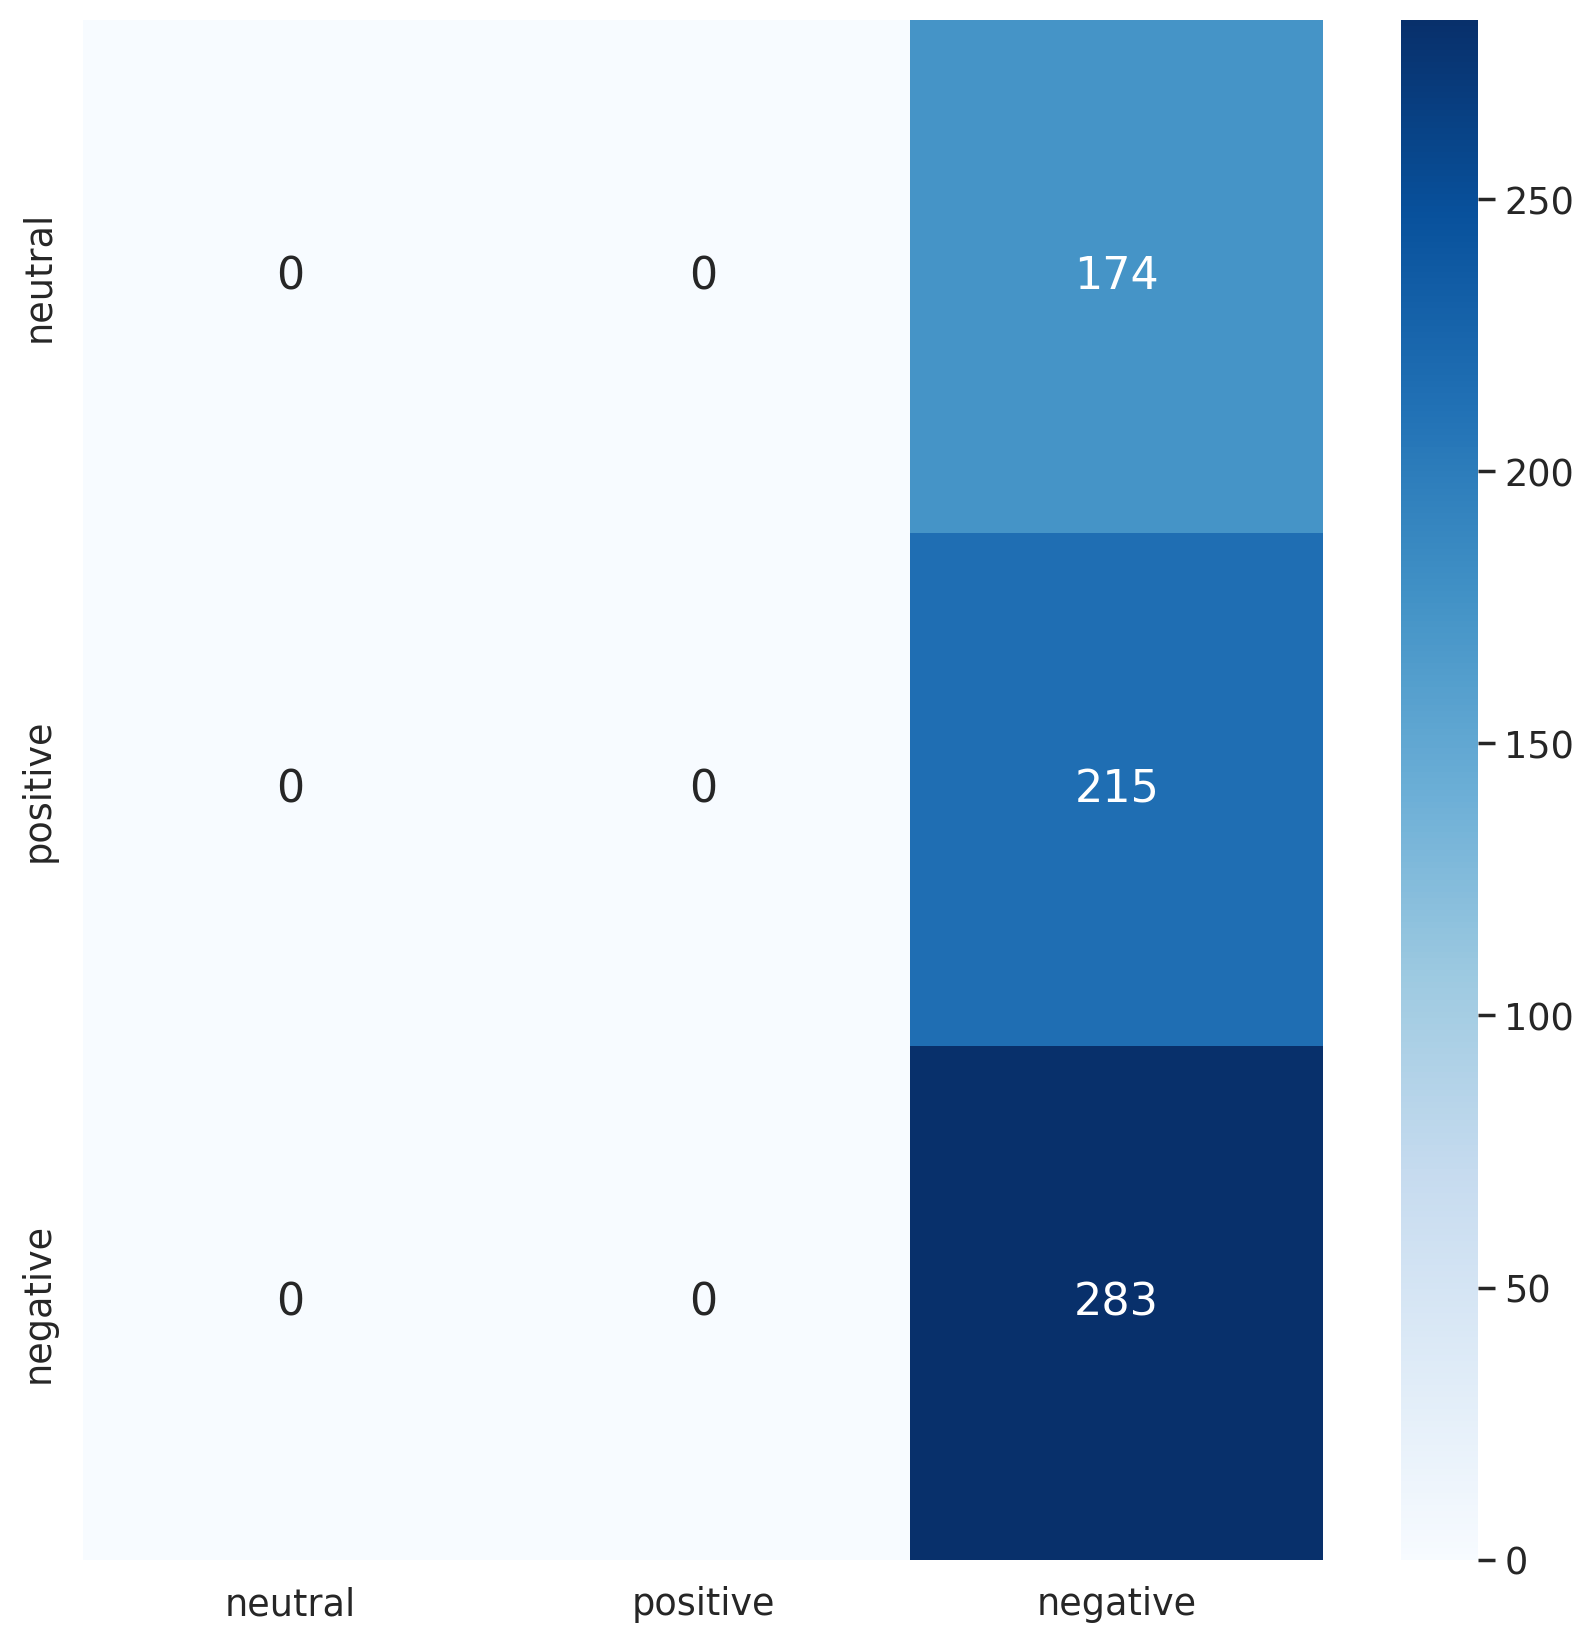

In [ ]:
#visualize confusion matrix for val set

cm_df_val = np.asarray(cf_matrix_val).reshape(3,3)

print(cm_df_val.shape)
plt.figure(figsize = (10,10))
sns.heatmap(cm_df_val, annot=True, fmt='', cmap='Blues',annot_kws={"size": 16}, xticklabels=class_names, yticklabels=class_names)
plt.show()

(3, 3)


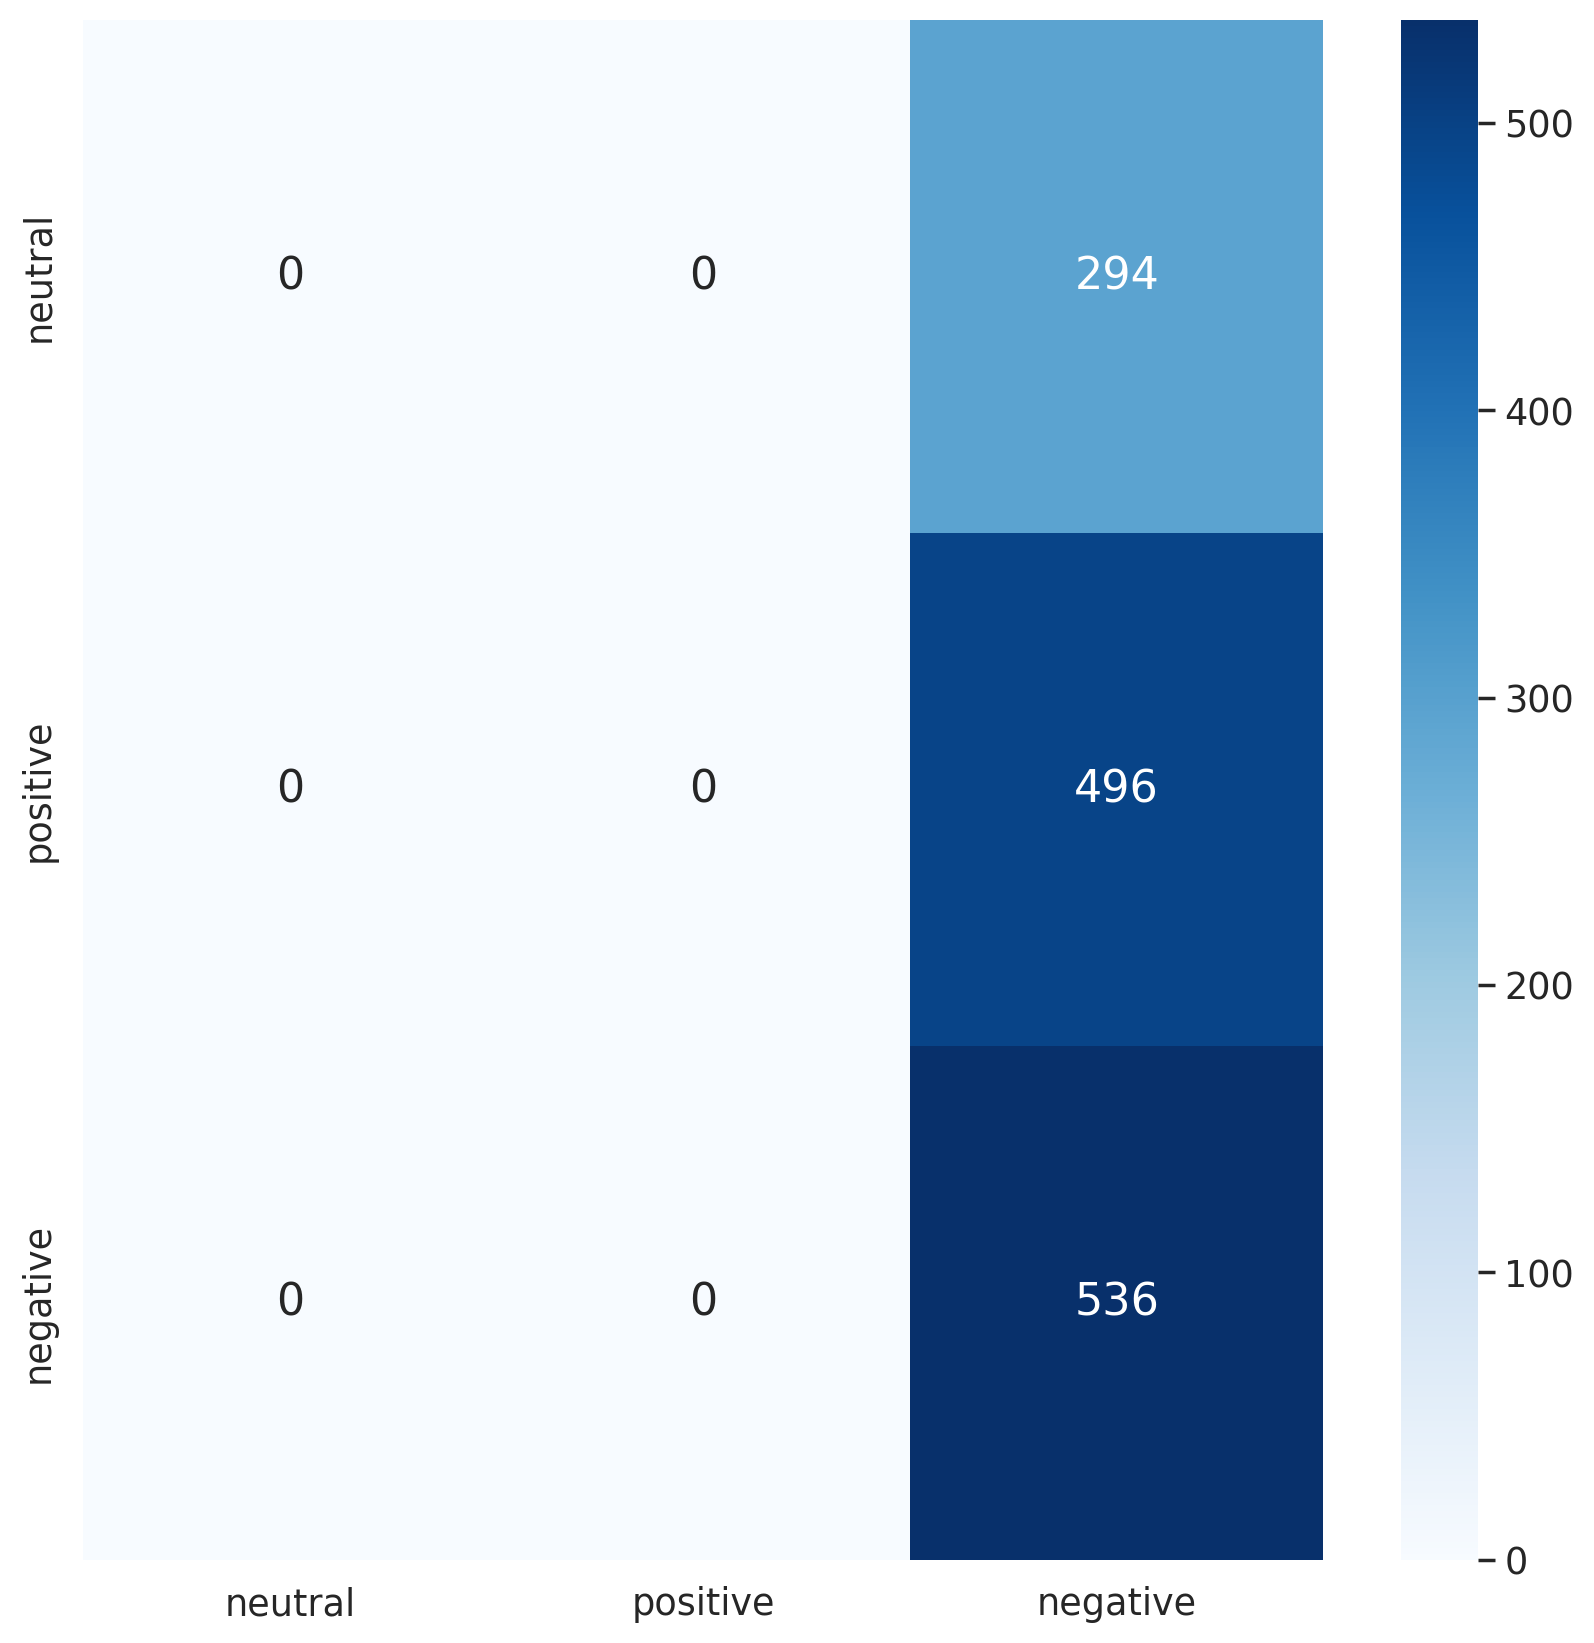

In [ ]:
#visualize confusion matrix for test set

cm_df_test = np.asarray(cf_matrix_test).reshape(3,3)

print(cm_df_test.shape)
plt.figure(figsize = (10,10))
sns.heatmap(cm_df_test, annot=True, fmt='', cmap='Blues',annot_kws={"size": 16}, xticklabels=class_names, yticklabels=class_names)
plt.show()

# All Data



N_EPOCHS = 5
BATCH_SIZE = 8


###**AraBERT**
'aubmindlab/bert-base-arabertv02' not segmentaion

**Sentiment**



* f1_macro is: 0.4509589882209433  
* f1_micro is : 0.6025641025641025


###**xlm-roberta-base**
* f1_macro is: 0.39813007415223184
* f1_micro is : 0.5377073906485671


###**AraBERT**
'aubmindlab/bert-base-arabertv2' segmentaion

**Sentiment**

f1_macro is: 0.4118878060969515
f1_micro is : 0.5558069381598794













# Subset of Data
N_EPOCHS = 20
BATCH_SIZE = 32

**Sentiment**


AraBERT



*   f1_micro is : 0.7727272727272727
*   f1_macro is: 0.7457276053266985


**ِEmotion**


AraBERT

* f1_macro is: 0.5190883952335663
* f1_micro is : 0.6515151515151515






N_EPOCHS = 5
BATCH_SIZE = 8

**Sentiment**


AraBERT



*   f1_micro is : 0.5454545454545454
*   f1_macro is: 0.39873870607653633


N_EPOCHS = 30
BATCH_SIZE = 32

**Sentiment**


AraBERT



*   f1_micro is : 0.6988636363636364
*   f1_macro is: 0.6686301164157916
